# Planet growth tracks: dead zone vs no dead zone

Loads two saved runs and overplots their planet growth tracks in the $M$–$R$ plane:

- **Dead-zone model** → **solid** lines
- **No-dead-zone model** → **dashed** lines

Lines are coloured by each planet's initial distance. Black **X** markers show where a
planet crossed the dead-zone boundary ($R_{\rm dz}$) as it migrated inward.

In [1]:
import os
import json
import numpy as np
import h5py
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
import matplotlib.cm as cm

## Loader
Self-contained copy of `load_history_hdf5` (same format the run notebooks write).

In [2]:
def load_history_hdf5(filename):
    """Load a run saved with save_history_hdf5.

    Returns
    -------
    history : dict      reconstructed time-series (same keys as the run)
    torque_maps : dict  {'t_yr', 'maps'}
    R : ndarray         disc cell-centre radii [AU]
    params : dict or None  the saved parameter dict
    """
    history = {}
    torque_maps = {}

    with h5py.File(filename, 'r') as f:
        R = f['R'][:]

        for key in ['t_yr', 'Mtot', 'Rout', 'Mdot_star', 'R_dz',
                    'Sigma_G', 'Sigma_D', 'dust_frac', 'St',
                    'grain_size', 'T', 'P', 'mid_gas_dens',
                    'chem_ice', 'chem_gas', 'Mdot_r', 'R_faces']:
            if key in f:
                history[key] = f[key][:]

        # planets: stored only from first implanted snapshot onward; re-pad earlier
        # snapshots with empty arrays so indices line up with t_yr.
        n_snaps = len(history['t_yr'])
        history['planets_R']     = [np.array([]) for _ in range(n_snaps)]
        history['planets_Mcore'] = [np.array([]) for _ in range(n_snaps)]
        history['planets_Menv']  = [np.array([]) for _ in range(n_snaps)]
        if 'planets' in f and 'R' in f['planets']:
            first = f['planets'].attrs['first_snap']
            pl_R     = f['planets/R'][:]
            pl_Mcore = f['planets/Mcore'][:]
            pl_Menv  = f['planets/Menv'][:]
            for j in range(pl_R.shape[0]):
                history['planets_R'][first + j]     = pl_R[j]
                history['planets_Mcore'][first + j] = pl_Mcore[j]
                history['planets_Menv'][first + j]  = pl_Menv[j]

        if 'torque_maps' in f:
            torque_maps['t_yr'] = f['torque_maps/t_yr'][:]
            torque_maps['maps'] = f['torque_maps/maps'][:]

        params = None
        if 'params_json' in f.attrs:
            params = json.loads(f.attrs['params_json'])

    return history, torque_maps, R, params

## Configure the two runs

Edit `DEADZONE_FILE` / `NODZ_FILE` to compare different runs. A few that exist in `output/`:

**Dead zone (solid):**
- `CASCA_planets2/PlanetsStaticDZ_Rdz_5.00_diskmass_0.10_alphaSS_1e-05_Mdot_1.0e-08/run_data.h5`  (3 Myr)
- `CASCA_planets2/PlanetsNoMigration_Rdz_5.00_diskmass_0.10_alphaSS_1e-05_Mdot_1.0e-08/run_data.h5`

**No dead zone (dashed):**
- `CASCA_planets_psiConstant copy/1Myr_diskmass_0.10_alphaSS_1e-04_Mdot_1.0e-08/run_data.h5`
- `CASCA_planets_psiConstant/viscous_diskmass_0.10_alphaSS_1e-03_Mdot_1.0e-08/run_data.h5`

In [3]:
_BASE = os.path.join(os.getcwd(), 'output')

# Dead-zone model -> SOLID lines
DEADZONE_FILE = os.path.join(
    _BASE, 'CASCA_planets2',
    'PlanetsStaticDZ_Rdz_5.00_diskmass_0.10_alphaSS_1e-05_Mdot_1.0e-08',
    'run_data.h5')

# No-dead-zone model -> DASHED lines
NODZ_FILE = os.path.join(
    _BASE, 'CASCA_planets_psiConstant copy',
    '1Myr_diskmass_0.10_alphaSS_1e-04_Mdot_1.0e-08',
    'run_data.h5')

# Seeding (identical for both models): R0 in AU, Mcore = 0.01 Mearth, Menv = 0
SEED_R0 = np.array([1., 2., 3., 4., 5., 7., 10., 15., 20., 25., 30.])
SEED_M0 = 0.01
IMPLANT_TIME_YR = 0.06e6   # planets implanted at 0.06 Myr

for tag, p in [('dead zone', DEADZONE_FILE), ('no dead zone', NODZ_FILE)]:
    print(f"{tag:>13}: {'OK      ' if os.path.exists(p) else 'MISSING '}{p}")

hist_dz, _, _, params_dz = load_history_hdf5(DEADZONE_FILE)
hist_nz, _, _, params_nz = load_history_hdf5(NODZ_FILE)

# Dead-zone boundary radius (constant 5 AU in these runs; fall back if not stored)
_rdz = hist_dz.get('R_dz')
R_DZ = float(_rdz[0]) if (_rdz is not None and len(_rdz) > 0) else 5.0

print(f"\nDead-zone boundary R_dz = {R_DZ:.2f} AU")
print(f"dead zone : {params_dz['output']['subfolder']}  (t_final = {params_dz['time']['t_final_Myr']} Myr)")
print(f"no dz     : {params_nz['output']['subfolder']}  (t_final = {params_nz['time']['t_final_Myr']} Myr)")

    dead zone: OK      /Users/james/Documents/GitHub/DiscEvolution/james/may2026/output/CASCA_planets2/PlanetsStaticDZ_Rdz_5.00_diskmass_0.10_alphaSS_1e-05_Mdot_1.0e-08/run_data.h5
 no dead zone: OK      /Users/james/Documents/GitHub/DiscEvolution/james/may2026/output/CASCA_planets_psiConstant copy/1Myr_diskmass_0.10_alphaSS_1e-04_Mdot_1.0e-08/run_data.h5

Dead-zone boundary R_dz = 5.00 AU
dead zone : PlanetsStaticDZ_Rdz_5.00_diskmass_0.10_alphaSS_1e-05_Mdot_1.0e-08  (t_final = 3.0 Myr)
no dz     : 1Myr_diskmass_0.10_alphaSS_1e-04_Mdot_1.0e-08  (t_final = 1.0 Myr)


## Build tracks and detect dead-zone crossings
The first saved planet snapshot can already be well after implantation, so we prepend the
known $0.01\,M_\oplus$ seed at the implant time. This also makes early boundary crossings
(e.g. the embryo seeded at 7 AU) detectable.

In [4]:
def build_tracks(history, seed_R0=SEED_R0, seed_M0=SEED_M0,
                 implant_time_yr=IMPLANT_TIME_YR, prepend_seed=True):
    """Return a list of (t_yr, R, Mtot) arrays, one per planet."""
    pr, pmc, pme = history['planets_R'], history['planets_Mcore'], history['planets_Menv']
    first = next((s for s in range(len(pr)) if len(pr[s]) > 0), None)
    if first is None:
        return []
    snaps = list(range(first, len(history['t_yr'])))
    t = np.array([history['t_yr'][s] for s in snaps], dtype=float)
    n = len(pr[first])
    tracks = []
    for i in range(n):
        R    = np.array([pr[s][i] for s in snaps], dtype=float)
        Mtot = np.array([pmc[s][i] + pme[s][i] for s in snaps], dtype=float)
        t_i  = t
        if prepend_seed and i < len(seed_R0):
            t_i  = np.concatenate([[implant_time_yr], t])
            R    = np.concatenate([[seed_R0[i]], R])
            Mtot = np.concatenate([[seed_M0], Mtot])
        tracks.append((t_i, R, Mtot))
    return tracks


def find_crossings(t, R, M, R_boundary):
    """Times/masses where a track crosses R_boundary (strict inward/outward sign change)."""
    out = []
    d = np.asarray(R, float) - R_boundary
    for k in range(len(d) - 1):
        if d[k] * d[k + 1] < 0:
            frac = d[k] / (d[k] - d[k + 1])
            t_c = t[k] + frac * (t[k + 1] - t[k])
            m0, m1 = max(M[k], 1e-12), max(M[k + 1], 1e-12)            # interp mass in log
            M_c = 10 ** (np.log10(m0) + frac * (np.log10(m1) - np.log10(m0)))
            out.append((t_c, R_boundary, M_c))
    return out


dz_tracks = build_tracks(hist_dz)
nz_tracks = build_tracks(hist_nz)
n_planets = min(len(dz_tracks), len(nz_tracks))
print(f"Dead-zone planets: {len(dz_tracks)}, No-dz planets: {len(nz_tracks)}, plotting {n_planets}")

Dead-zone planets: 11, No-dz planets: 11, plotting 11


## Plot

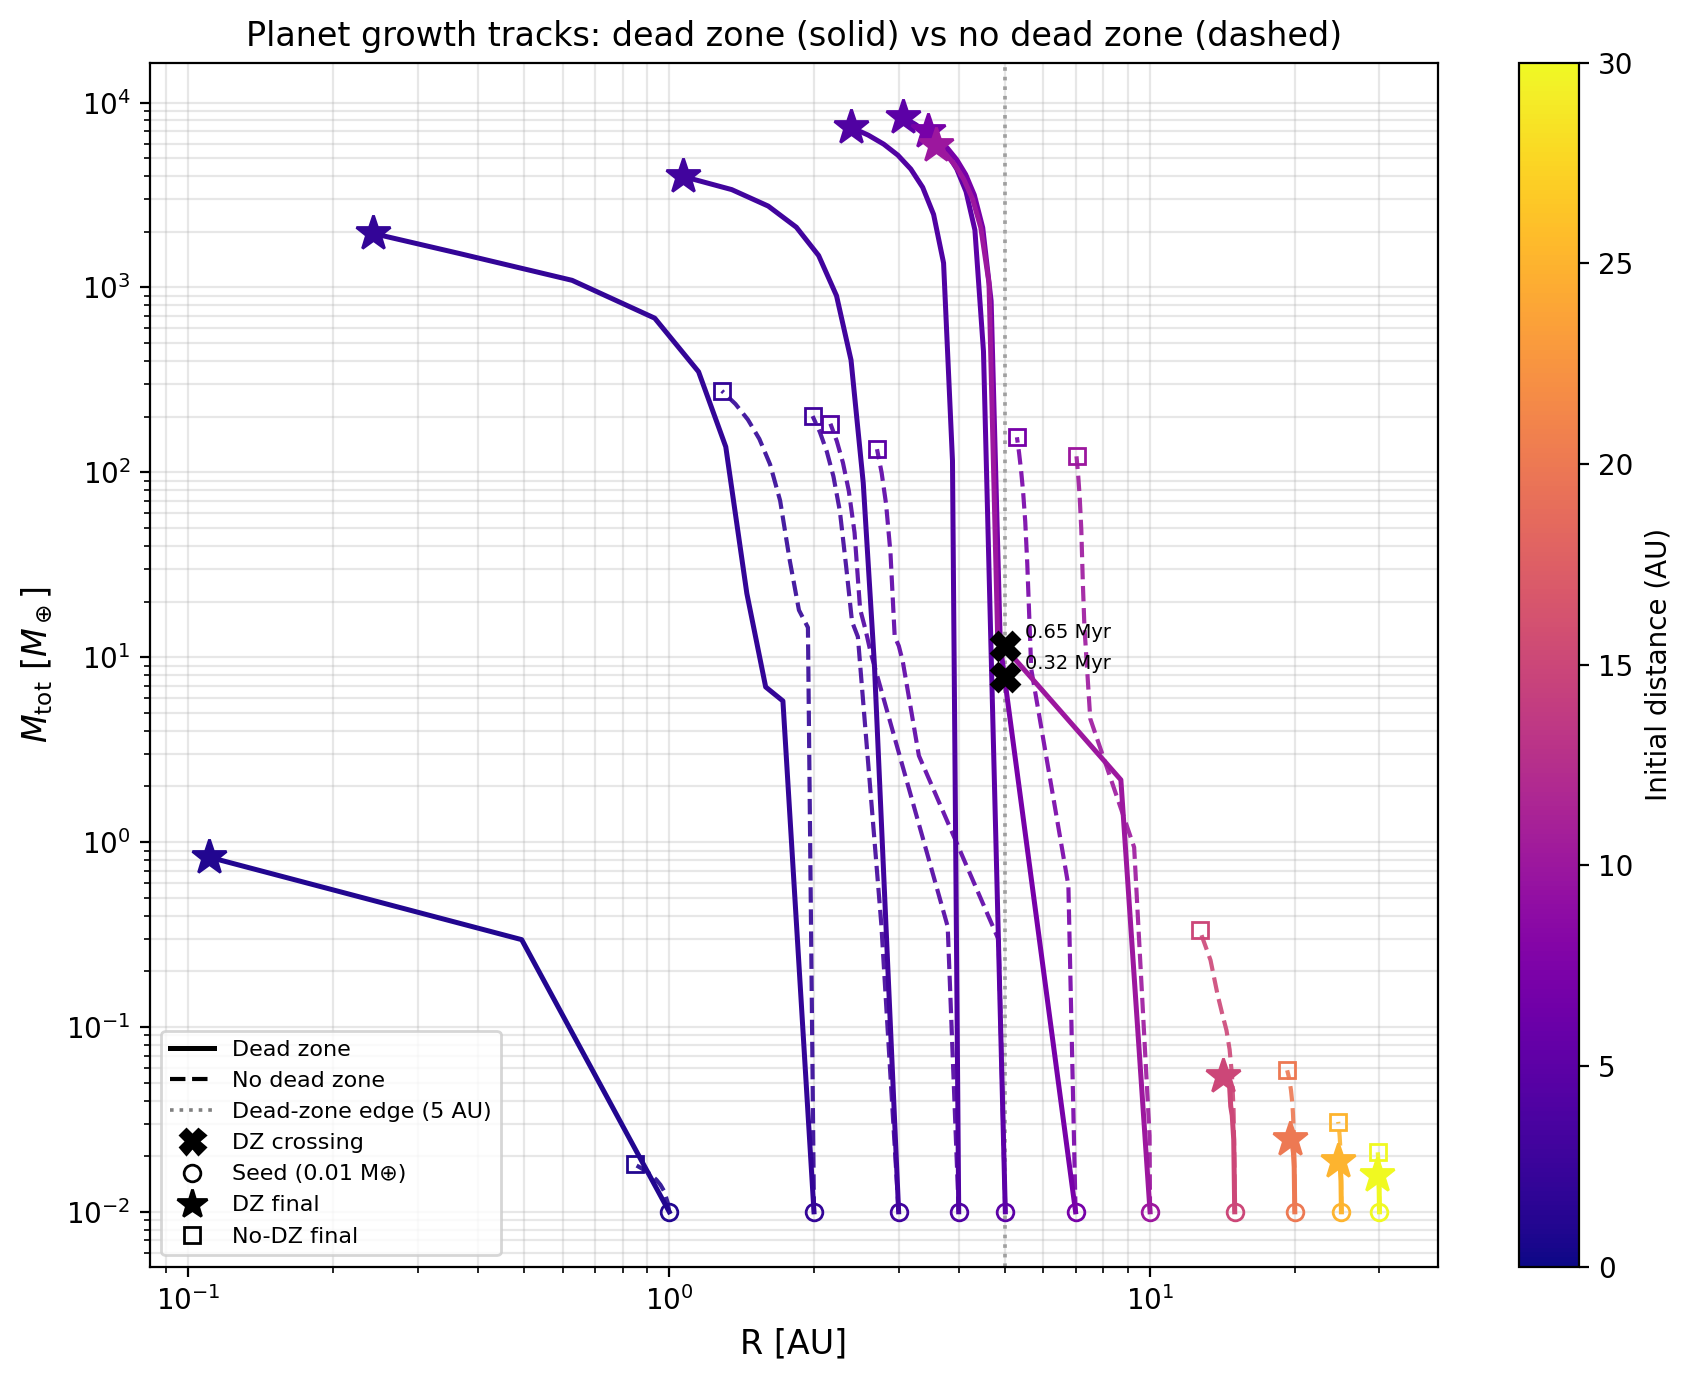

Dead-zone boundary crossings (planet, R0[AU], t_cross[Myr], M_cross[Mearth]):
  planet  5  R0=  7.0   t= 0.32 Myr   M=    7.777
  planet  6  R0= 10.0   t= 0.65 Myr   M=   11.499


In [5]:
fig, ax = plt.subplots(figsize=(9, 7), dpi=200)

cmap = plt.cm.plasma
norm = Normalize(vmin=0, vmax=float(SEED_R0[:n_planets].max()))

# Dead-zone boundary
ax.axvline(R_DZ, color='grey', ls=':', lw=1.3, alpha=0.8, zorder=1)

cross_pts = []
for i in range(n_planets):
    color = cmap(norm(SEED_R0[i]))

    # dead-zone model: SOLID
    t_d, R_d, M_d = dz_tracks[i]
    ax.plot(R_d, M_d, '-', color=color, lw=1.8, zorder=3)
    ax.plot(R_d[0],  M_d[0],  'o', mfc='none', mec=color, ms=6,  zorder=4)   # seed
    ax.plot(R_d[-1], M_d[-1], '*', color=color, ms=13, zorder=5)            # final

    for (t_c, R_c, M_c) in find_crossings(t_d, R_d, M_d, R_DZ):
        ax.plot(R_c, M_c, 'X', color='k', ms=10, zorder=6)
        ax.annotate(f'{t_c/1e6:.2f} Myr', (R_c, M_c),
                    textcoords='offset points', xytext=(7, 3), fontsize=7, zorder=7)
        cross_pts.append((i, float(SEED_R0[i]), t_c / 1e6, M_c))

    # no-dead-zone model: DASHED
    t_n, R_n, M_n = nz_tracks[i]
    ax.plot(R_n, M_n, '--', color=color, lw=1.5, alpha=0.9, zorder=2)
    ax.plot(R_n[-1], M_n[-1], 's', mfc='none', mec=color, ms=6, zorder=4)   # final

# colour bar = initial distance
sm = cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
cb = plt.colorbar(sm, ax=ax); cb.set_label('Initial distance (AU)')

# style legend
proxies = [
    Line2D([0], [0], color='k', ls='-',  lw=1.8, label='Dead zone'),
    Line2D([0], [0], color='k', ls='--', lw=1.5, label='No dead zone'),
    Line2D([0], [0], color='grey', ls=':', lw=1.3, label=f'Dead-zone edge ({R_DZ:.0f} AU)'),
    Line2D([0], [0], color='k', marker='X', ls='none', ms=9,  label='DZ crossing'),
    Line2D([0], [0], color='k', marker='o', mfc='none', ls='none', ms=6, label='Seed (0.01 M⊕)'),
    Line2D([0], [0], color='k', marker='*', ls='none', ms=11, label='DZ final'),
    Line2D([0], [0], color='k', marker='s', mfc='none', ls='none', ms=6, label='No-DZ final'),
]
ax.legend(handles=proxies, fontsize=8, loc='lower left')

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('R [AU]', fontsize=12)
ax.set_ylabel(r'$M_{\rm tot}\ [M_\oplus]$', fontsize=12)
ax.set_title('Planet growth tracks: dead zone (solid) vs no dead zone (dashed)', fontsize=12)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()

_OUT = os.path.join(os.getcwd(), 'output', 'CASCA_plots')
os.makedirs(_OUT, exist_ok=True)
fig.savefig(os.path.join(_OUT, 'growth_tracks_dz_vs_nodz.png'), dpi=200, bbox_inches='tight')
plt.show()

if cross_pts:
    print("Dead-zone boundary crossings (planet, R0[AU], t_cross[Myr], M_cross[Mearth]):")
    for i, r0, tc, mc in cross_pts:
        print(f"  planet {i:2d}  R0={r0:5.1f}   t={tc:5.2f} Myr   M={mc:9.3f}")
else:
    print("No dead-zone boundary crossings detected.")